# Setup data

In [ ]:
from math import sin
from math import pi
from numpy import arange
from numpy import vstack
from numpy import argmax
from numpy import asarray
from numpy.random import normal
from numpy.random import random
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from warnings import catch_warnings
from warnings import simplefilter
from matplotlib import pyplot as plt

%matplotlib inline

params = {'legend.fontsize': 20,
          'legend.handlelength': 2,
          'figure.figsize':(25, 12)
          }
plt.rcParams.update(params)

Optima: x=0.900, y=0.810


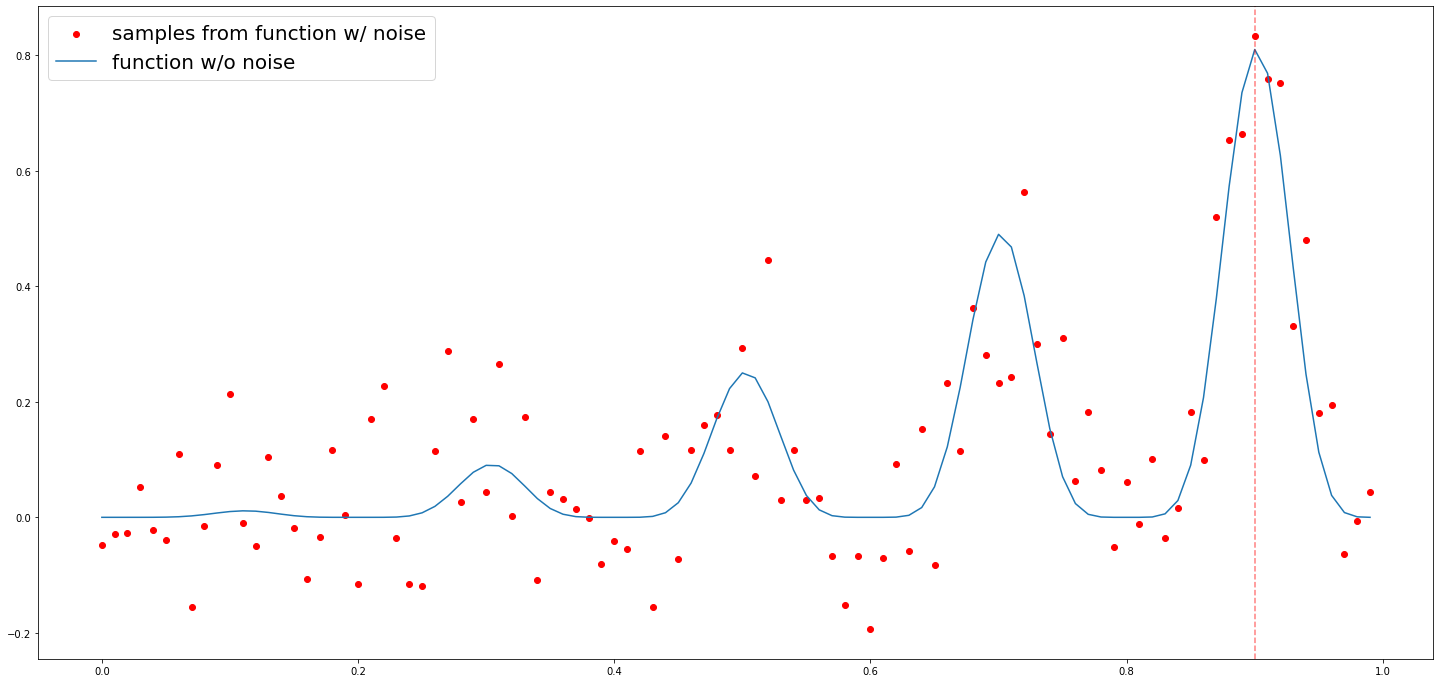

In [ ]:
# objective function
def objective(x, noise=0.1):
  noise = normal(loc=0, scale=noise)
  return (x**2 * sin(5 * pi * x)**6.0) + noise
 
# grid-based sample of the domain [0,1]
X = arange(0, 1, 0.01)
# sample the domain without noise
y = [objective(x, 0) for x in X]
# sample the domain with noise
ynoise = [objective(x) for x in X]

# plot the points with noise
plt.scatter(X, ynoise, color='red',label='samples from function w/ noise')
# plot the target function
plt.plot(X, y, label='function w/o noise')

# find best result
ix = argmax(y)
print('Optima: x=%.3f, y=%.3f' % (X[ix], y[ix]))
plt.axvline(x=X[ix], linestyle='--', color='red', alpha=0.5)
plt.legend()

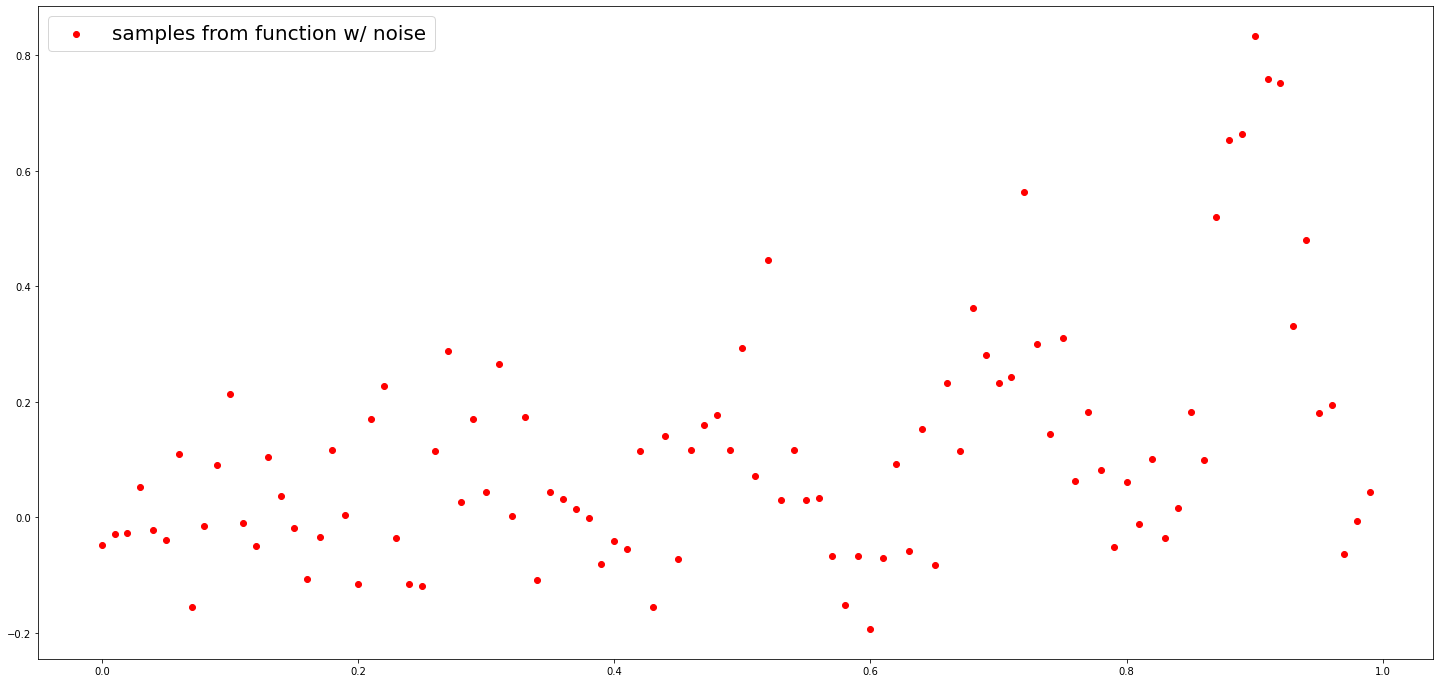

In [ ]:
# plot the observed points with noise
plt.scatter(X, ynoise, color='red', label='samples from function w/ noise')
plt.legend(loc=2, prop={'size': 20})

# Surrogate function
Gaussian Process

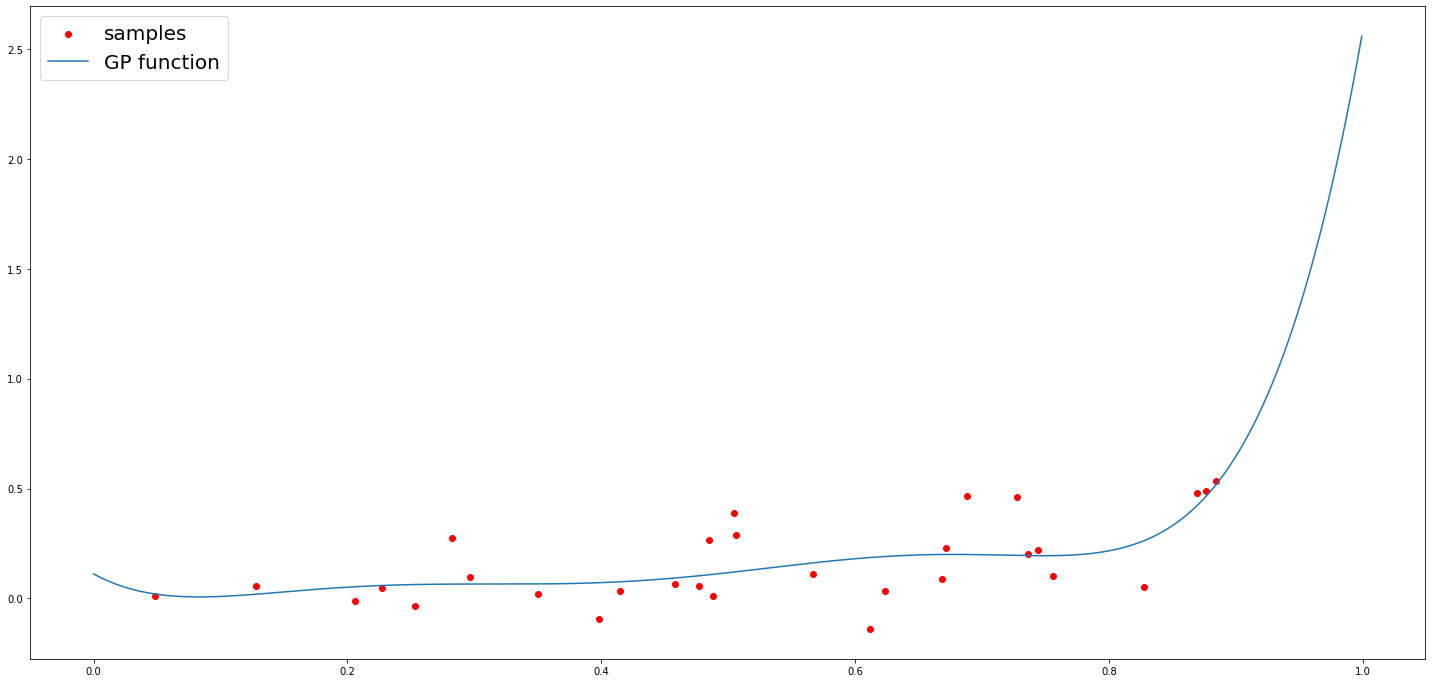

In [ ]:
# example of a gaussian process surrogate function
 
# objective function
def objective(x, noise=0.1):
  noise = normal(loc=0, scale=noise)
  return (x**2 * sin(5 * pi * x)**6.0) + noise
 
# surrogate or approximation for the objective function
def surrogate(model, X):
  return model.predict(X, return_std=True)
 
# plot real observations vs surrogate function
def plot(X, y, model):
  # scatter plot of inputs and real objective function
  plt.scatter(X, y, color='red', label='samples')
  # line plot of surrogate function across domain
  Xsamples = asarray(arange(0, 1, 0.001))
  Xsamples = Xsamples.reshape(len(Xsamples), 1)
  ysamples, _ = surrogate(model, Xsamples)
  plt.plot(Xsamples, ysamples, label='GP function')

# sample the domain sparsely with noise
X = random(30)
y = asarray([objective(x) for x in X])
# reshape into rows and cols
X = X.reshape(len(X), 1)
y = y.reshape(len(y), 1)
# define the model
model = GaussianProcessRegressor()
# fit the model
model.fit(X, y)
# plot the surrogate function
plot(X, y, model)
plt.legend(loc=2, prop={'size': 20})

# Acquisition function

In [ ]:
# optimize the acquisition function
def opt_acquisition(X, y, model):
  # random search, generate random samples
  Xsamples = random(100)
  Xsamples = Xsamples.reshape(len(Xsamples), 1)
  
  # calculate the acquisition function for each sample
  scores = acquisition(X, Xsamples, model)
  
  # locate the index of the largest scores
  ix = argmax(scores)
  return Xsamples[ix, 0]

# probability of improvement (PI) acquisition function
# return the most promising one 
def acquisition(X, Xsamples, model):
  # calculate the best surrogate score found so far
  yhat, _ = surrogate(model, X)
  best = max(yhat)
  
  # calculate mean and stdev via surrogate function
  mu, std = surrogate(model, Xsamples)
  mu = mu[:, 0]

  # calculate the probability of improvement
  probs = norm.cdf((mu - best) / (std+1E-9))
  
  return probs

# Test


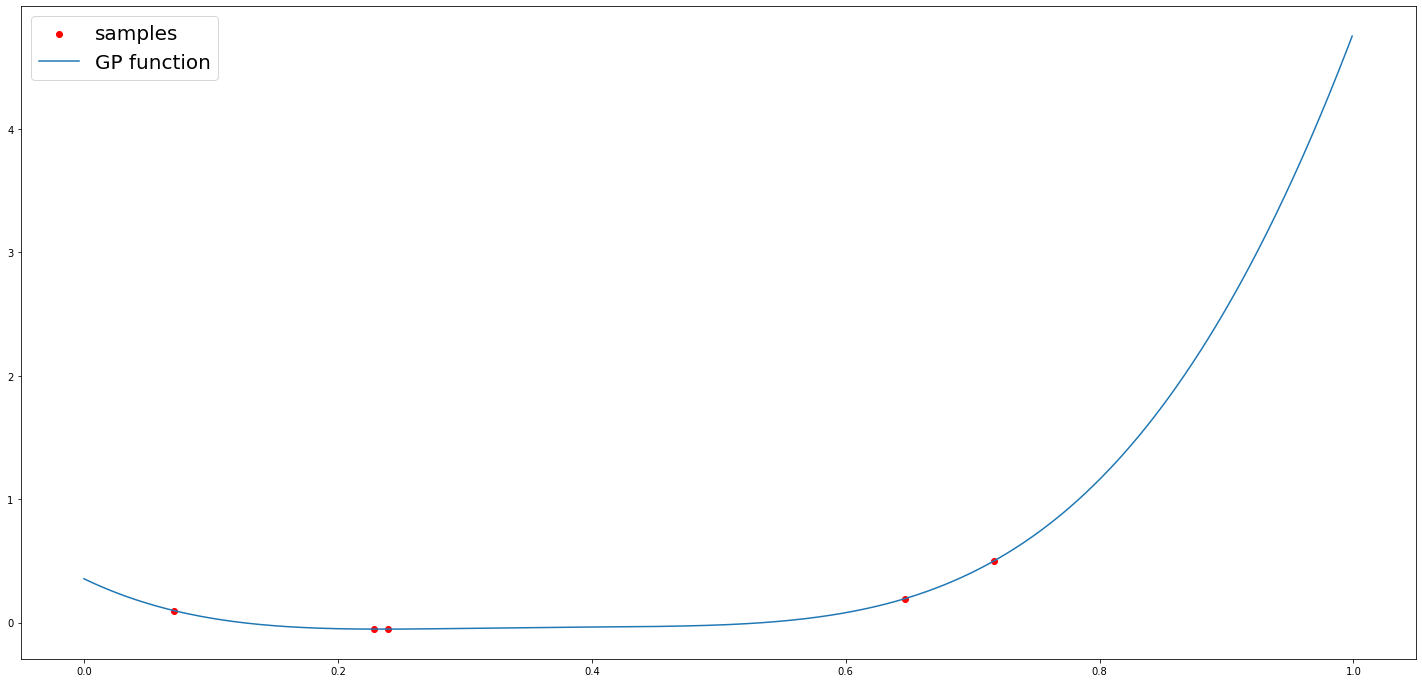

In [ ]:
# sample the domain sparsely with noise
X = random(5)
y = asarray([objective(x) for x in X])
# reshape into rows and cols
X = X.reshape(len(X), 1)
y = y.reshape(len(y), 1)

# define the model
model = GaussianProcessRegressor()
# fit the model
model.fit(X, y)
# plot before hand
plot(X, y, model)
plt.legend(loc=2, prop={'size': 20})

> x=0.979, f()=4.244872, actual=0.126


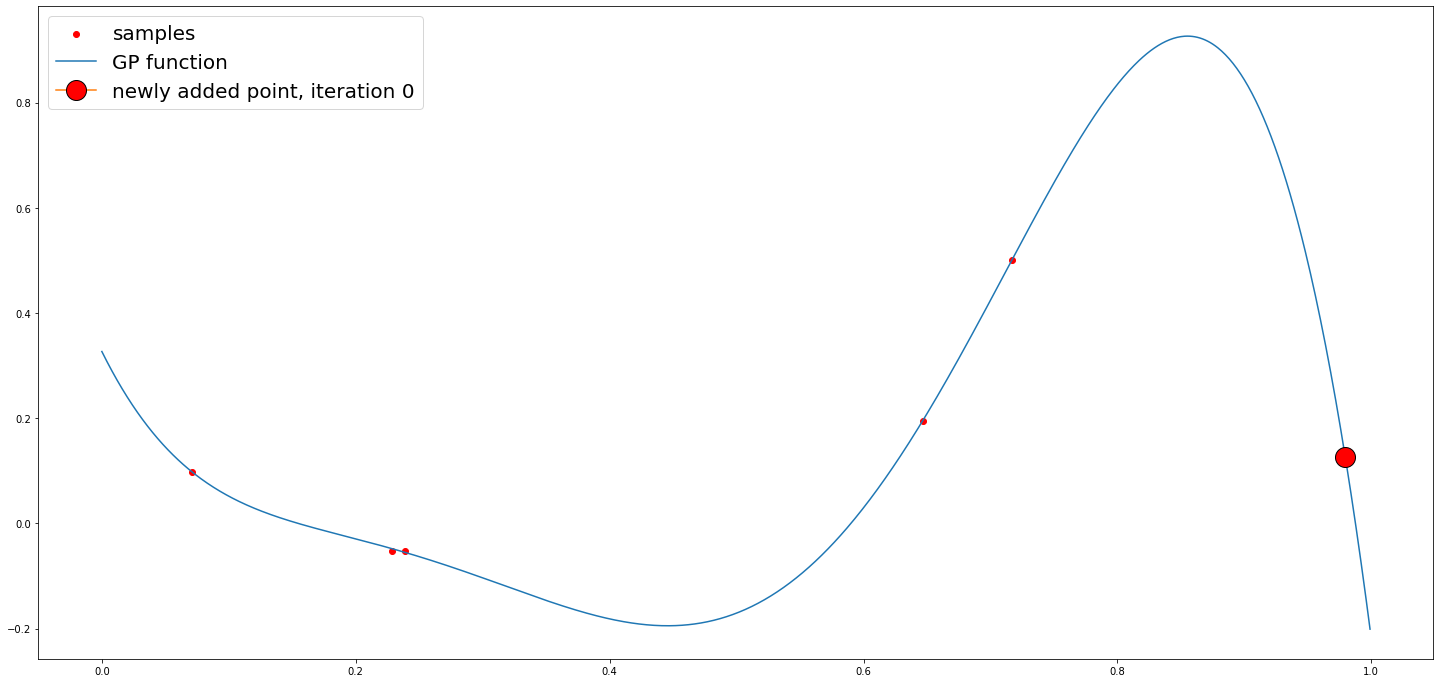

> x=0.937, f()=0.621862, actual=0.394


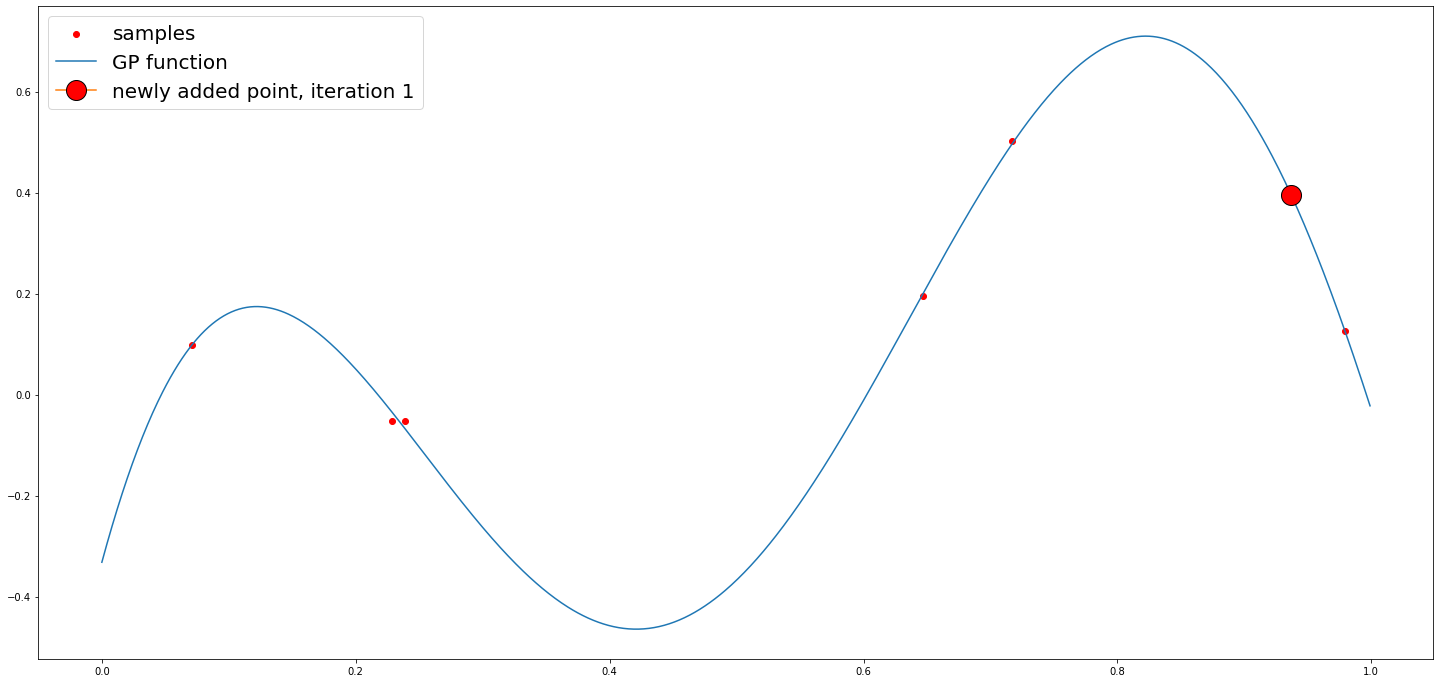

> x=0.814, f()=0.708446, actual=-0.135


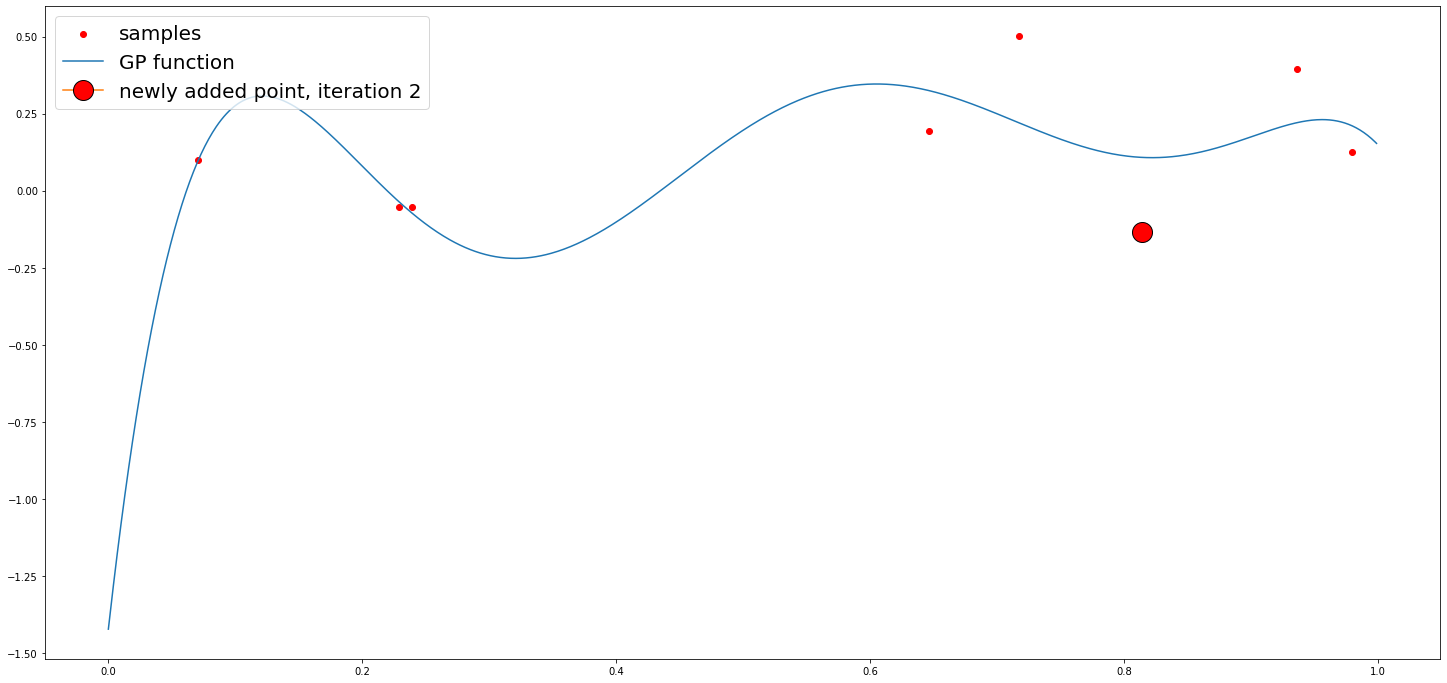

In [ ]:
# perform the Bayesian optimization process
for i in range(3):
  # select the next point to sample
  x = opt_acquisition(X, y, model)
  # print("acuqisition: {}".format(x))

  # sample the point
  actual = objective(x)

  # summarize the finding
  est, _ = surrogate(model, [[x]])
  print('> x=%.3f, f()=%3f, actual=%.3f' % (x, est, actual))

  # add the data to the dataset
  X = vstack((X, [[x]]))
  y = vstack((y, [[actual]]))
  
  # update the model
  model.fit(X, y)

  # plot all samples and the final surrogate function
  plot(X, y, model) 

  # plot the added new point
  plt.plot(x, actual, marker="o", markersize=20, markeredgecolor="black", markerfacecolor="red", label="newly added point, iteration %d" % i)

  plt.legend(loc=2, prop={'size': 20})
  plt.show()

Best Result: x=0.717, y=0.501


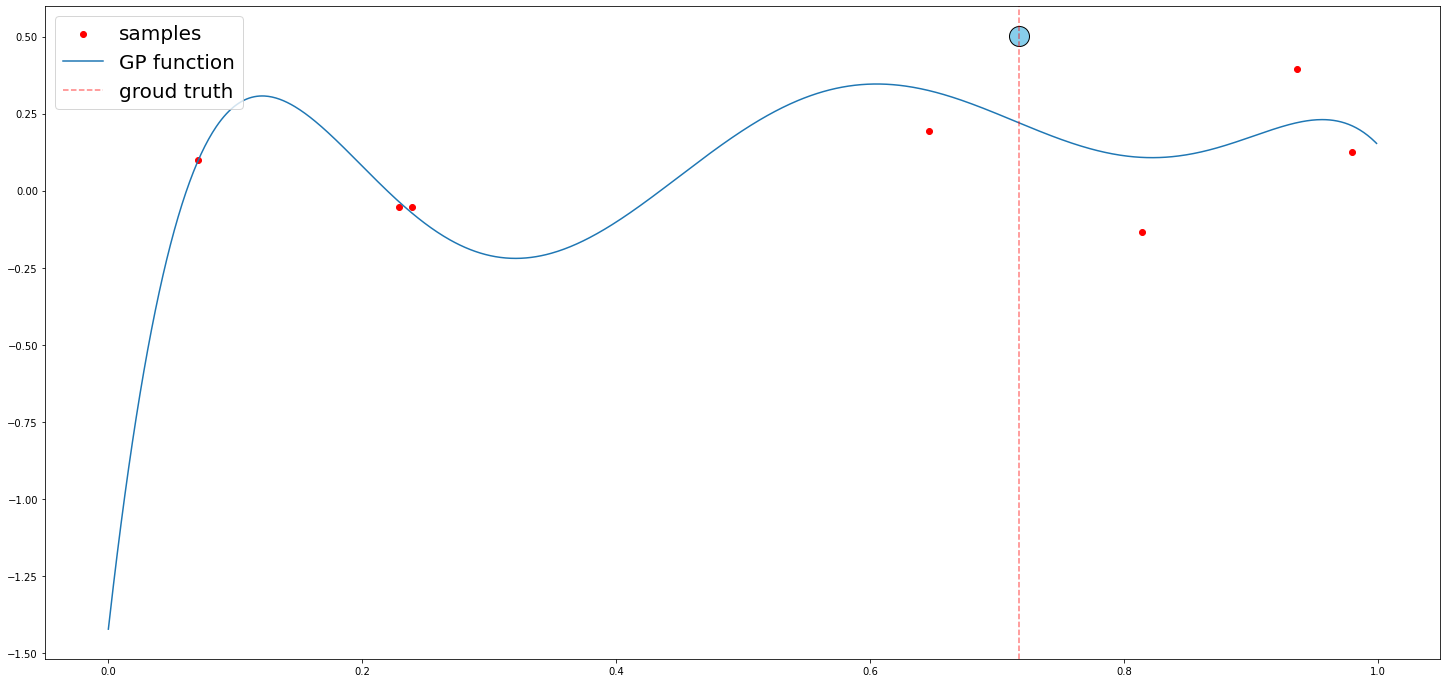

In [ ]:
plot(X, y, model) 
# best result
ix = argmax(y)
print('Best Result: x=%.3f, y=%.3f' % (X[ix], y[ix]))
plt.plot(X[ix], y[ix], marker="o", markersize=20, markeredgecolor="black", markerfacecolor="skyblue")
plt.axvline(x=X[ix], linestyle='--', color='red', alpha=0.5, label='groud truth')
plt.legend(loc=2, prop={'size': 20})